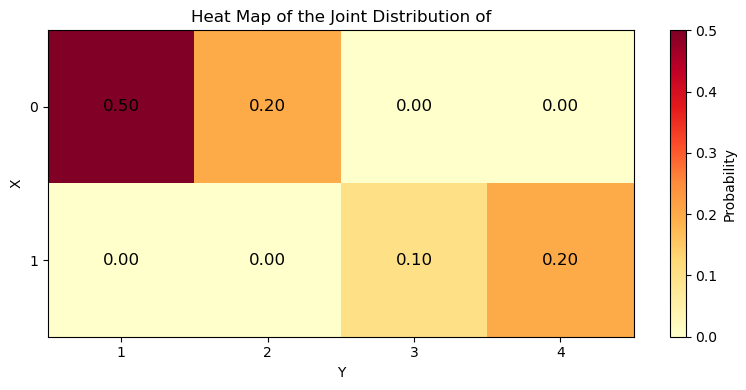

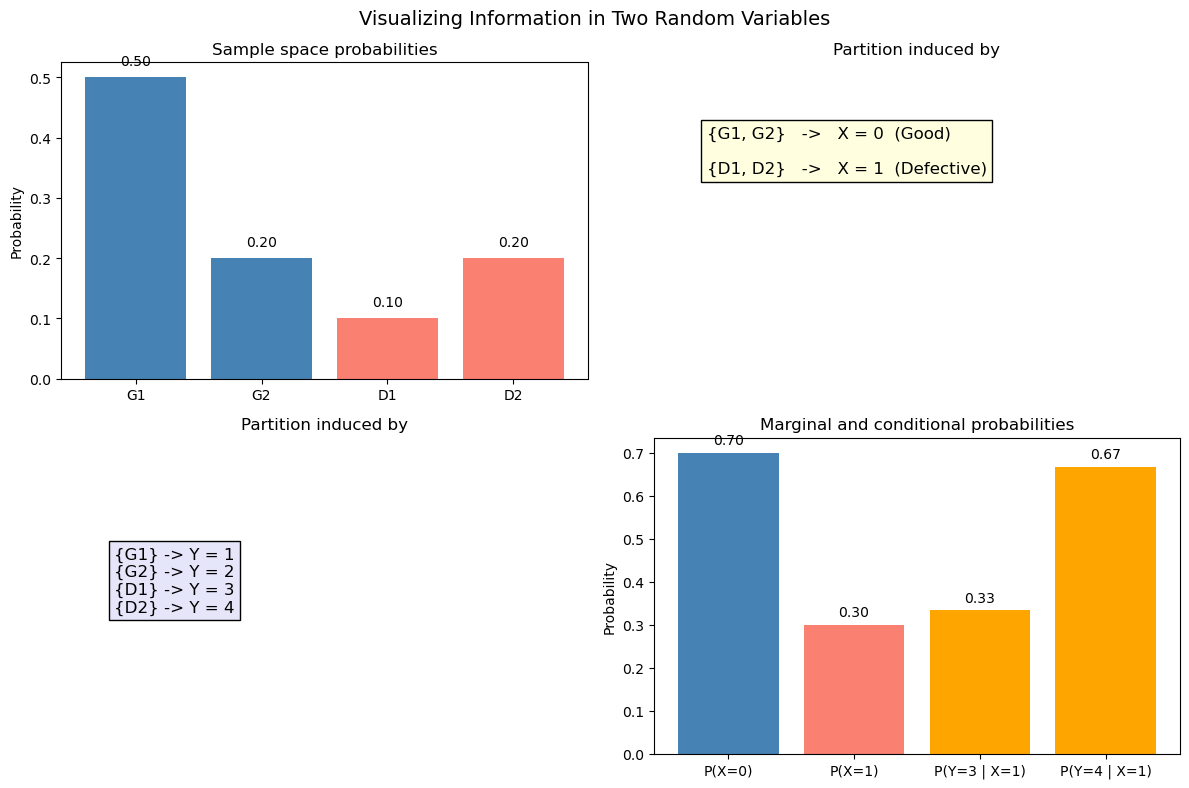

In [4]:

import matplotlib.pyplot as plt
import numpy as np

# Sample space probabilities
omega = ["G1", "G2", "D1", "D2"]
p = np.array([0.50, 0.20, 0.10, 0.20])

# Random variables
X = {"G1": 0, "G2": 0, "D1": 1, "D2": 1}
Y = {"G1": 1, "G2": 2, "D1": 3, "D2": 4}

# Marginals
px = {
    0: p[0] + p[1],
    1: p[2] + p[3]
}

py = {
    1: p[0],
    2: p[1],
    3: p[2],
    4: p[3]
}



# Joint distribution table for (X,Y)
# Rows correspond to X = 0, 1
# Columns correspond to Y = 1, 2, 3, 4

joint = np.array([
    [0.50, 0.20, 0.00, 0.00],  # X = 0
    [0.00, 0.00, 0.10, 0.20]   # X = 1
])

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(joint, cmap="YlOrRd", aspect="auto")

# Axis labels
ax.set_xticks(range(4))
ax.set_xticklabels([1, 2, 3, 4])
ax.set_yticks(range(2))
ax.set_yticklabels([0, 1])

ax.set_xlabel("Y")
ax.set_ylabel("X")
ax.set_title("Heat Map of the Joint Distribution of")

# Add probability values inside cells
for i in range(joint.shape[0]):
    for j in range(joint.shape[1]):
        ax.text(j, i, f"{joint[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=12)

# Color bar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Probability")

plt.tight_layout()
plt.show()

# Conditionals
p_y3_given_x1 = p[2] / (p[2] + p[3])
p_y4_given_x1 = p[3] / (p[2] + p[3])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Visualizing Information in Two Random Variables", fontsize=14)

# 1. Sample space probabilities
axes[0, 0].bar(omega, p, color=["steelblue", "steelblue", "salmon", "salmon"])
axes[0, 0].set_title("Sample space probabilities")
axes[0, 0].set_ylabel("Probability")
for i, val in enumerate(p):
    axes[0, 0].text(i, val + 0.02, f"{val:.2f}", ha="center")

# 2. Partition induced by X
axes[0, 1].axis("off")
axes[0, 1].set_title(r"Partition induced by")
axes[0, 1].text(
    0.1, 0.65,
    "{G1, G2}   ->   X = 0  (Good)\n\n{D1, D2}   ->   X = 1  (Defective)",
    fontsize=12,
    bbox=dict(facecolor="lightyellow", edgecolor="black")
)

# 3. Partition induced by Y
axes[1, 0].axis("off")
axes[1, 0].set_title(r"Partition induced by")
axes[1, 0].text(
    0.1, 0.45,
    "{G1} -> Y = 1\n{G2} -> Y = 2\n{D1} -> Y = 3\n{D2} -> Y = 4",
    fontsize=12,
    bbox=dict(facecolor="lavender", edgecolor="black")
)

# 4. Marginal of X and conditional of Y given X=1
x_labels = ["P(X=0)", "P(X=1)", "P(Y=3 | X=1)", "P(Y=4 | X=1)"]
x_vals = [px[0], px[1], p_y3_given_x1, p_y4_given_x1]
axes[1, 1].bar(x_labels, x_vals, color=["steelblue", "salmon", "orange", "orange"])
axes[1, 1].set_title("Marginal and conditional probabilities")
axes[1, 1].set_ylabel("Probability")
for i, val in enumerate(x_vals):
    axes[1, 1].text(i, val + 0.02, f"{val:.2f}", ha="center")

plt.tight_layout()
plt.show()

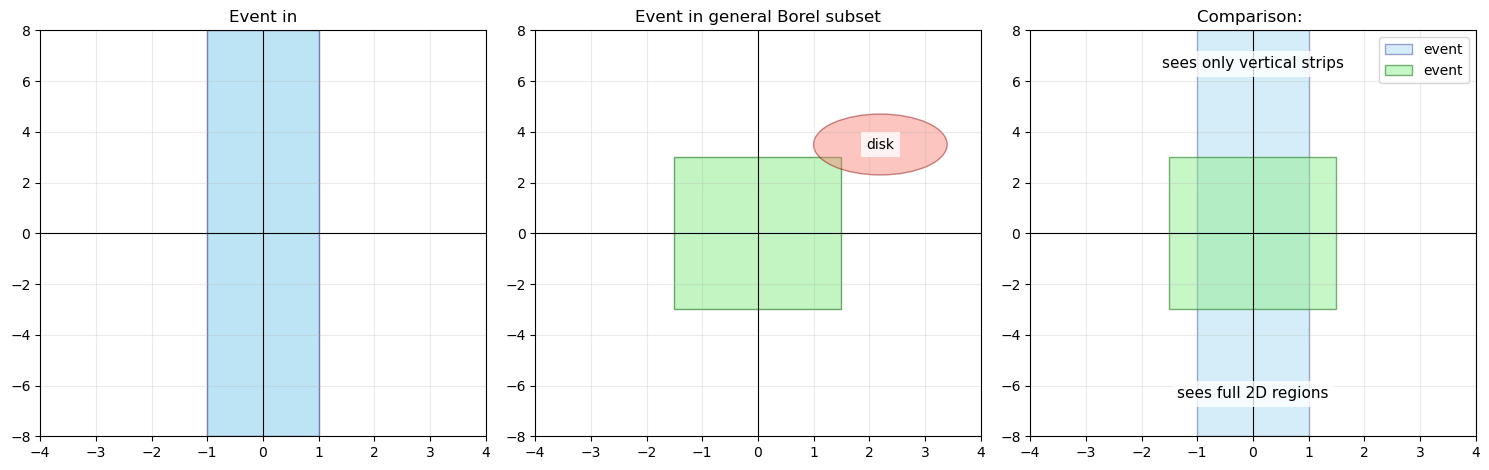

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

xlim = (-4, 4)
ylim = (-8, 8)

# -------------------------
# (1) Event in sigma(X)
# -------------------------
ax = axes[0]
ax.set_title(r"Event in")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"")
ax.set_ylabel(r"")

# Example B = [-1,1]
strip = Rectangle((-1, ylim[0]), 2, ylim[1] - ylim[0],
                  facecolor="skyblue", edgecolor="navy", alpha=0.55)
ax.add_patch(strip)

ax.text(0, 0, r"",
        ha="center", va="center", fontsize=12,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.grid(alpha=0.25)

# -------------------------
# (2) Event in sigma(Y)
# -------------------------
ax = axes[1]
ax.set_title(r"Event in general Borel subset")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"")
ax.set_ylabel(r"")

# Example rectangle in sigma(Y)
rect = Rectangle((-1.5, -3), 3, 6,
                 facecolor="lightgreen", edgecolor="darkgreen", alpha=0.55)
ax.add_patch(rect)

# Also add a disk to emphasize generality
disk = Circle((2.2, 3.5), 1.2,
              facecolor="salmon", edgecolor="darkred", alpha=0.45)
ax.add_patch(disk)

ax.text(0, 0, r"",
        ha="center", va="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
ax.text(2.2, 3.5, r"disk",
        ha="center", va="center", fontsize=10,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.grid(alpha=0.25)

# -------------------------
# (3) Comparison
# -------------------------
ax = axes[2]
ax.set_title(r"Comparison: ")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"")
ax.set_ylabel(r"")

# Vertical strip for sigma(X)
strip2 = Rectangle((-1, ylim[0]), 2, ylim[1] - ylim[0],
                   facecolor="skyblue", edgecolor="navy", alpha=0.35,
                   label=r"event")
ax.add_patch(strip2)

# Rectangle for sigma(Y)
rect2 = Rectangle((-1.5, -3), 3, 6,
                  facecolor="lightgreen", edgecolor="darkgreen", alpha=0.5,
                  label=r"event")
ax.add_patch(rect2)

ax.text(0, 6.5, r"sees only vertical strips",ha="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
ax.text(0, -6.5, r"sees full 2D regions",
        ha="center", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.legend(loc="upper right")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()
     

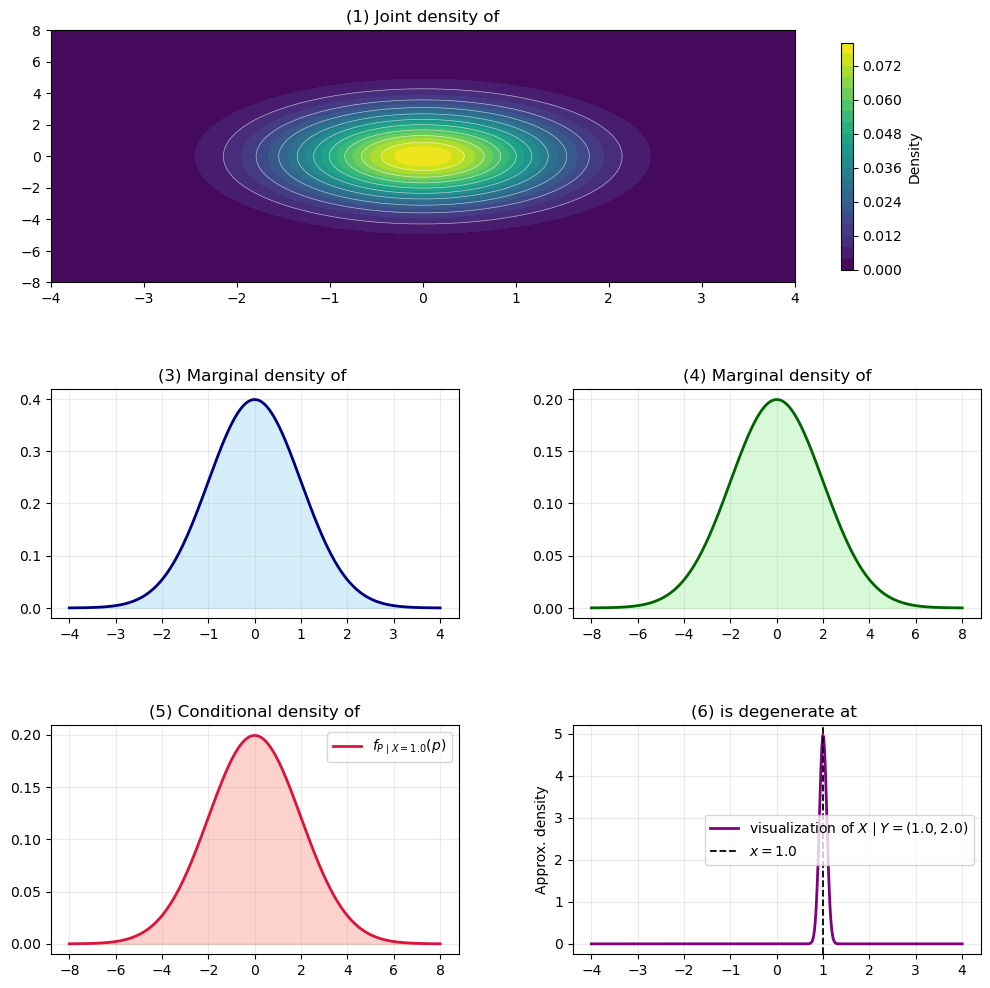

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# Parameters
mu_T, sigma_T = 0.0, 1.0
mu_P, sigma_P = 0.0, 2.0   # since Var(P)=4

# Grids
t = np.linspace(-4, 4, 400)
p = np.linspace(-8, 8, 400)
T, P = np.meshgrid(t, p)

# Joint density of Y = (T, P)
joint_pdf = (
    norm.pdf(T, loc=mu_T, scale=sigma_T) *
    norm.pdf(P, loc=mu_P, scale=sigma_P)
)

# Marginal density of X = T
fx = norm.pdf(t, loc=mu_T, scale=sigma_T)

# Conditional density of P | X=t0
# Independence implies P | X=t0 ~ N(0,4)
t0 = 1.0
cond_p_given_x = norm.pdf(p, loc=mu_P, scale=sigma_P)

# Conditional distribution of X | Y=(t1,p1):
# Degenerate at t1, approximated here by a narrow Gaussian just for visualization
t1, p1 = 1.0, 2.0
eps = 0.08
cond_x_given_y_vis = norm.pdf(t, loc=t1, scale=eps)

# Figure with subplot layout:
# 1
# 3 4
# 5 6
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 1], hspace=0.45, wspace=0.28)

# (1) Joint contour spanning full top row
ax1 = fig.add_subplot(gs[0, :])
cs = ax1.contourf(T, P, joint_pdf, levels=25, cmap="viridis")
ax1.contour(T, P, joint_pdf, levels=10, colors="white", linewidths=0.5, alpha=0.6)
ax1.set_title(r"(1) Joint density of")
ax1.set_xlabel(r"")
ax1.set_ylabel(r"")
fig.colorbar(cs, ax=ax1, shrink=0.9, label="Density")

# (3) Marginal of X
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(t, fx, color="navy", lw=2)
ax3.fill_between(t, fx, color="skyblue", alpha=0.35)
ax3.set_title(r"(3) Marginal density of ")
ax3.set_xlabel(r"")
ax3.set_ylabel(r"")
ax3.grid(alpha=0.25)

# (4) Marginal of P
ax4 = fig.add_subplot(gs[1, 1])
fp = norm.pdf(p, loc=mu_P, scale=sigma_P)
ax4.plot(p, fp, color="darkgreen", lw=2)
ax4.fill_between(p, fp, color="lightgreen", alpha=0.35)
ax4.set_title(r"(4) Marginal density of")
ax4.set_xlabel(r"")
ax4.set_ylabel(r"")
ax4.grid(alpha=0.25)

# (5) Conditional density of P | X=t0
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(p, cond_p_given_x, color="crimson", lw=2,
         label=rf"$f_{{P\mid X={t0}}}(p)$")
ax5.fill_between(p, cond_p_given_x, color="salmon", alpha=0.35)
ax5.set_title(r"(5) Conditional density of")
ax5.set_xlabel(r"")
ax5.set_ylabel(r"")
ax5.legend()
ax5.grid(alpha=0.25)

# (6) Visualized conditional of X | Y=(t1,p1)
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(t, cond_x_given_y_vis, color="purple", lw=2,
         label=rf"visualization of $X\mid Y=({t1},{p1})$")
ax6.axvline(t1, color="black", ls="--", lw=1.3, label=rf"$x={t1}$")
ax6.set_title(r"(6) is degenerate at ")
ax6.set_xlabel(r"")
ax6.set_ylabel("Approx. density")
ax6.legend()
ax6.grid(alpha=0.25)

plt.show()
     